# 实验一　全连接神经网络 

<br>


## 实验说明
<br>

　　<font color=black size=3 face=雅黑> 使用像 TensorFlow 和 PyTorch 这样的高级框架（deep learning framework）能够让我们方便、快速地构建各类神经网络模型。然而，理解神经网络的基本概念和内部原理对初学者来说同样重要。在本次实验中，我们将学习如何使用 Numpy 构建一个全连接神经网络，并利用它来处理分类任务，通过实践加深对神经网络内部机制的理解。

　　<font color=black size=3 face=雅黑> 本次实验我们将主要使用如下 Python 库：
        
　　　　<font color=black size=3 face=雅黑> - Numpy: Python 科学计算库
   
       
<code>
%%html
<img src ="https://gimg2.baidu.com/image_search/src=http%3A%2F%2Fwww.wazhi.com.cn%2Fschool%2Fimage%2F1169%2F20200728%2F20200728051325463.jpg&refer=http%3A%2F%2Fwww.wazhi.com.cn&app=2002&size=f9999,10000&q=a80&n=0&g=0n&fmt=jpeg?sec=1635389536&t=97e1d309d9c32fe9a4a1b934f033b45f", width=20%>



## 背景知识

<br>

<font color=black size=3 face=雅黑>　　全连接神经网络（Fully-Connected Neual Network）是一种最简单、基础的神经网络，有时也叫作多层感知器（Multi-Layer Perceptron，MLP）。它的网络结构如下图所示，包含输入层 (input layer)、若干隐藏层 (hidden layers) 及输出层 (output layer)，层内神经元之间无连接，层与层之间神经元全连接。
    
<font color=black size=3 face=雅黑>　　在开始实验之前，请同学们回顾全连接神经网络的基本知识，包括参数和信息的表示方式、前向传播和反向传播的运算规则等。

<code>
%%html
<img src = "https://gimg2.baidu.com/image_search/src=http%3A%2F%2Fpic1.zhimg.com%2Fv2-ed7d12d37fa954829b8875b491ca03ee_1440w.jpg%3Fsource%3D172ae18b&refer=http%3A%2F%2Fpic1.zhimg.com&app=2002&size=f9999,10000&q=a80&n=0&g=0n&fmt=jpeg?sec=1635396426&t=6107e7aa8fb941009d5d5b9140d8f0bb", width=50%>



## 实验步骤

<br>

### 0. 概览 
    
<font color=black size=3 face=雅黑>　　我们的目标是创建一个具有特定网络结构的全连接神经网络，然后训练它实现分类任务。实验开始前，我们先来看一下神经网络模型训练的整个过程。
    
<font color=black size=3 face=雅黑>　　神经网络训练可以划分为前向传播 (forward propagation) 和反向传播 (backward propagation) 两个部分，其计算分别如下图所示。
    
<font color=black size=3 face=雅黑>　　下图前向传播过程中，神经网络输入数据表示为 **$x$**，输出表示为 **$y\_hat$**。各层权重矩阵用 **$W^{[l]}$** 表示，偏置向量用 **$b^{[l]}$** 表示，权重矩阵与激活向量相乘后再与偏置向量相加，其结果用 **$z^{[l]}$** 表示。各层最终输出的激活向量表示为 **$a^{[l]}$**，$a^{[l]}=g(z^{[l]})$ ($g$为激活函数)。最后一层的输出激活向量即为神经网络输出，即$a^{[L]}$=$y\_hat$。最终，损失函数 (loss function) 会根据网络输出 **$y\_hat$** 与标准结果 **$y$** (golden results) 算出损失。

<font color=black size=3 face=雅黑>　　在反向传播过程中，需要用到前向传播的中间数据，包括各层的 **$a^{[l]}$** 和 **$z^{[l]}$**。反向传播由最后一层开始，到第一层结束，期间需要根据链式法则逐层计算损失关于权重 **$W^{[l]}$** 和偏置 **$b^{[l]}$** 的偏导数。**$dW^{[l]}$** 和 **$db^{[l]}$** 计算完成后，对 **$W^{[l]}$** 和 **$b^{[l]}$** 进行更新，至此完成一次迭代。
    
<code>
%%html   
<img src = "https://pic4.zhimg.com/v2-f06b5d07704d965a3c65078ffd7d95af_b.webp", width=60%>
<code>
%%html
<img src = "https://pic3.zhimg.com/v2-ffb7dc9760f74bc720f2745eda6d777e_r.jpg", width=60%>
    


### 1. Import Numpy

In [1]:
import numpy as np

In [2]:
print(np.__version__)

2.2.6



### 2. 导入其他 Python 库 （Import Other Libraries）

In [3]:
import os
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

<br />

### 3. 定义神经网络结构

<br />


<font color=black size=3 face=雅黑>　　我们的程序将以列表（list）的形式描述神经网络结构（neural network architecture），之后我们可以很容易地对网络结构进行修改。列表的每一项是一个字典（dictionary），描述单个网络层的基本结构。其中，"input_dim"是该层输入信号向量的长度，"output_dim"是该层输出激活向量的长度，"activation"是该网络层所用的激活函数（如 sigmoid 和 ReLU）。
    
<font color=black size=3 face=雅黑>　　此处需要注意的是，一个网络层的输出向量同时也是下一层的输入。因此，第 m 层的"input_dim"应当与第 m-1 层"output_dim"保持一致。

<br />
    
<font color=black size=3 face=雅黑>　　稍后请同学们尝试不同的网络的结构，看看训练结果是否有什么不同，分析其趋势及原因。
    
<font color=black size=3 face=雅黑>　　例如：    
    
<font color=black size=3 face=雅黑>　　　　- 增加神经网络层数

<font color=black size=3 face=雅黑>　　　　- 减少神经网络层数 
    
<font color=black size=3 face=雅黑>　　　　- 增加或减少各层输入和输出的维度（"input_dim", "output_dim"） 
    
<font color=black size=3 face=雅黑>　　　　- 使用 Sigmoind 函数代替 ReLU 

<br />

In [ ]:
NN_ARCHITECTURE = [
    {"input_dim": 2, "output_dim": 25, "activation": "relu"},
    {"input_dim": 25, "output_dim": 50, "activation": "relu"},
    {"input_dim": 50, "output_dim": 50, "activation": "relu"},
    {"input_dim": 50, "output_dim": 25, "activation": "relu"},
    {"input_dim": 25, "output_dim": 1, "activation": "sigmoid"},
]

# 结构A：减层 + 减维（3层）
NN_ARCHITECTURE_A = [
    {"input_dim": 2, "output_dim": 16, "activation": "relu"},
    {"input_dim": 16, "output_dim": 16, "activation": "relu"},
    {"input_dim": 16, "output_dim": 1, "activation": "sigmoid"},
]

# 结构B：加层 + 增维（6层）
NN_ARCHITECTURE_B = [
    {"input_dim": 2, "output_dim": 50, "activation": "relu"},
    {"input_dim": 50, "output_dim": 100, "activation": "relu"},
    {"input_dim": 100, "output_dim": 100, "activation": "relu"},
    {"input_dim": 100, "output_dim": 50, "activation": "relu"},
    {"input_dim": 50, "output_dim": 25, "activation": "relu"},
    {"input_dim": 25, "output_dim": 1, "activation": "sigmoid"},
]

# 结构C：全Sigmoid（5层不变，但激活改为sigmoid）
NN_ARCHITECTURE_C = [
    {"input_dim": 2, "output_dim": 25, "activation": "sigmoid"},
    {"input_dim": 25, "output_dim": 50, "activation": "sigmoid"},
    {"input_dim": 50, "output_dim": 50, "activation": "sigmoid"},
    {"input_dim": 50, "output_dim": 25, "activation": "sigmoid"},
    {"input_dim": 25, "output_dim": 1, "activation": "sigmoid"},
]

<br>

### 4. 初始化神经网络

<br>

#### <font color=black size=3 face=雅黑>4.1 理解权重矩阵 **$W$** 和偏置向量 **$b$**

<font color=black size=3 face=雅黑>　　定义好了网络结构，接下来就要初始化网络参数（权重及偏置）。每一层网络的权重矩阵和偏置向量如下图所示：

<br>
    
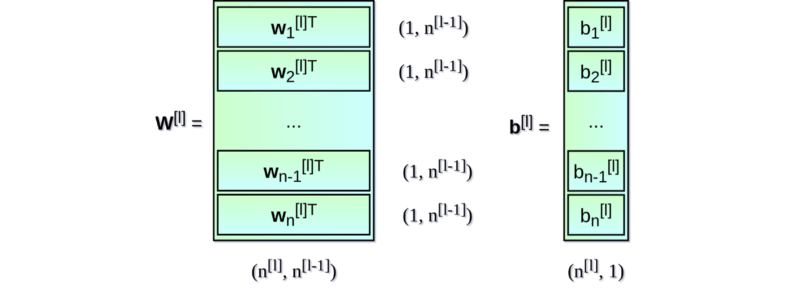
    
<br>
    
<font color=black size=3 face=雅黑>　　其中，上标 [$l$] 表示当前层的索引，下标 $n$ 表示给定层中的神经元数量。当前层 **$W$** 的形状为 $(n^{[l]},n^{[l-1]})$，**$b$** 的形状为 $(n^{[l]},1)$。
    
<font color=black size=3 face=雅黑>　　请同学们注意区分上图中的矩阵、向量和标量：其中，矩阵用粗体大写字母表示，向量用粗体小写字母表示，标量用普通小写字母表示。
    
<br>


#### <font color=black size=3 face=雅黑>4.2 参数初始化方法

<font color=black size=3 face=雅黑>　　下面我们可以开始逐层初始化权重矩阵和偏置向量。神经网络参数初始化对于模型训练很重要，不良的初始值会导致梯度传播问题，降低训练速度，甚至导致模型无法收敛；而良好的初始值则能够加快收敛速度，并且更可能找到较优解。 

<font color=black size=3 face=雅黑>　　下面，我们将随机赋一个小数值给 **$W$** 和 **$b$** 的各个元素。这里随机赋值是非常重要的，我们不能使用完全相同的数字（例如 0）来初始化参数值，否则无法打破神经网络的对称性，会使得训练无法顺利进行。可以想见，如果所有权重都取相同值，那么不管输入是什么，隐藏层中的所有单元都会是相同的，那么反向传播算法计算出来的梯度值也是相同的，参数更新后仍将保持一致。这种情况下，无论我们训练模型多久、网络有多深，都会陷入在初始状态中。将权重随机初始化为小数值是打破网络对称性的一个普遍方法。
    
<font color=black size=3 face=雅黑>　　那么使用较小的初值又是为什么呢？这里我们以 Sigmoid 函数作为例子来说明。请同学们观察下面 Sigmoid 函数及其导函数曲线图（蓝色-sigmoid，橙色-导数）。

<code>
%%html   
<img src = "https://img-blog.csdnimg.cn/20190716205739176.png?x-oss-process=image/watermark,type_ZmFuZ3poZW5naGVpdGk,shadow_10,text_aHR0cHM6Ly95aXNodWloYW5jaGVuZy5ibG9nLmNzZG4ubmV0,size_16,color_FFFFFF,t_70", width=55%>
    
<font color=black size=3 face=雅黑>　　可以看到，Sigmoid 导函数取值范围在(0,0.25]之间，当输入值较大时，Sigmoid 导数值趋近于0，这可能会导致权重的更新量很小，对神经网络的训练速度造成影响。使用较小的随机数初始化模型可以让之后的模型训练有一个足够好的起点。当然，也不是数值越小就会表现的越好。如果一个神经网络层的所有权重都非常小，那么在反向传播过程中得到的梯度值也将非常小，对于比较深的神经网络来讲，可能会导致“梯度消失”问题。


#### <font color=black size=3 face=雅黑>4.3 尝试不同的参数初始化方法

<font color=black size=3 face=雅黑>　　同学们稍后请修改下面“init_layer”函数对应的代码，做如下尝试，看看训练结果和上面的有什么不同。 
    
<font color=black size=3 face=雅黑>　　　- 将所有参数初始化为 0
    
<br>

In [ ]:
def init_layers(nn_architecture_a, seed = 99):
    np.random.seed(seed)
    number_of_layers = len(nn_architecture_a)
    params_values = {}

    for idx, layer in enumerate(nn_architecture_a):
        
        layer_idx = idx + 1  # note: we number network layers from 1
        layer_input_size = layer["input_dim"]
        layer_output_size = layer["output_dim"]

        # initialize W and b

        ###############  Please finish this part  ################
        
        # [Hint]: 
        #    params_values['W' + str(layer_idx)] = np.random.randn(XXX, XXX) * 0.1
        #    params_values['b' + str(layer_idx)] = np.random.randn(XXX, 1) * 0.1
        
        # 初始化权重矩阵W: 形状为(output_dim, input_dim)
        params_values['W' + str(layer_idx)] = np.random.randn(layer_output_size, layer_input_size) * 0.1
        
        # 初始化偏置向量b: 形状为(output_dim, 1)
        params_values['b' + str(layer_idx)] = np.random.randn(layer_output_size, 1) * 0.1
        
        
        ########################  end  ###########################

    return params_values

<br />

### 5. 实现激活函数

<font color=black size=3 face=雅黑>　　激活函数虽然简单，只需一行代码就可定义，但对神经网络来说非常重要。没有激活函数的话，神经网络将变成线性函数的组合，大大降低了其表达能力。激活函数有很多种。在本次实验中，我们将选用如下两种激活函数：
    
<font color=black size=3 face=雅黑>　　　　－　Sigmoid 函数
    
<font color=black size=3 face=雅黑>　　　　－　ReLU 函数

<br />

<font color=black size=3 face=雅黑>　　接下来我们需要分别实现它们的前向传播（forward）和反向传播（backward）运算。Sigmoid 及 ReLU 的函数曲线和导函数曲线分别如下图中所示。请同学们阅读如下代码，并在留白处根据提示填写相应的代码，实现 ReLU 函数的正传和反传过程。

<br />

<code>
%%html   
<img src = "https://pic3.zhimg.com/v2-a658865c292b86272dd141074d902936_b.webp", width=80%>

In [6]:
def sigmoid(Z):
    return 1/(1+np.exp(-Z))

    
def sigmoid_backward(dA, Z):
    sig = sigmoid(Z)
    return dA * sig * (1 - sig)


def relu(Z):
    
    ###############  Please finish this part  ################
    
    # [Hint]: use the following numpy function 
    #  —— np.maximum(XXX, XXX)
    
    # ReLU激活函数: f(x) = max(0, x)
    # 使用 np.maximum 函数返回 Z 和 0 之间的最大值
    return np.maximum(0, Z)
    
    
    ########################  end  ###########################


def relu_backward(dA, Z):
    
    dZ = np.array(dA, copy = True)
    
    ###############  Please finish this part  ################
    
    # [Hint]: use one-line code to mask some entries in dZ to 0
    #     dZ[XXX] = 0
    
    # ReLU的导数: 当Z <= 0时，导数为0；当Z > 0时，导数为1
    # 将Z <= 0的位置的梯度设为0
    dZ[Z <= 0] = 0
   
    ########################  end  ###########################
    
    return dZ

<br />

### 6. 实现神经网络的前向传播过程

<font color=black size=3 face=雅黑>　　对整个神经网络来说，输入 $x$ 传入网络后将逐层向前传播，并最终在网络末端得到输出向量 **$y\_hat$**。为了让代码更易读，接下来我们将把前向传播过程拆分成两个函数来实现：

<font color=black size=3 face=雅黑>　　－　函数 6-1 (single_layer_forward_propagation)： 实现单个全连接层的前向传播过程

<font color=black size=3 face=雅黑>　　－　函数 6-2 (full_forward_propagation)： 基于函数 6-1，实现整个全连接神经网络的前向传播过程

<br />

#### <font color=black size=3 face=雅黑>6.1　函数 6-1 （single_layer_forward_propagation）：实现单个全连接层的前向传播过程

<br>
    
<font color=black size=3 face=雅黑>　　相对于反向传播来讲，神经网络层的前向传播过程比较直观。这里我们假设来自上一层的输入信号为 **$a\_prev$**，当前层的权重矩阵和偏置向量分别为 **$W\_curr$** 和 **$b\_curr$**。首先，我们需要实现 **$W\_curr$** 和 **$a\_prev$** 之间的矩阵乘法运算，并将结果与 **$b\_curr$** 相加，得到 **$z\_curr$**。这一部分运算我们将通过 Numpy 完成。基于 NumPy，我们可以对整个网络层和整批 (batch) 样本一次性进行矩阵操作，无需迭代，这大大简化了我们的代码，也加速了计算。

<font color=black size=3 face=雅黑>　　这个运算过程如下图所示，请注意理解每个矩阵和向量的维度：
    
<code>
%%html
<img src = "https://pic2.zhimg.com/v2-b999ab8463b39b4d83a3c8b34ba24d61_r.jpg", width=80%>
    

<font color=black size=3 face=雅黑>　　接着，我们需要对矩阵运算结果应用所选的激活函数，由 $z\_curr$ 得到 $a\_curr$。
    
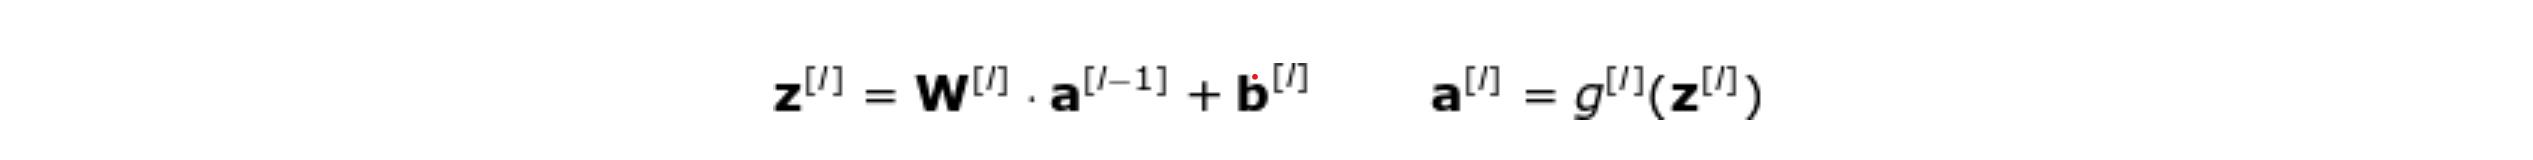
    
<font color=black size=3 face=雅黑>　　函数的输出除了经过激活函数处理的最终结果 $a\_curr$ 外，还包含中间结果 $z\_curr$，这是因为我们将在反向传播时用到这些中间数据。
    
<br>

In [7]:
def single_layer_forward_propagation(A_prev, W_curr, b_curr, activation="relu"):

    # calculate Z_curr

    ###############  Please finish this part  ################
    
    # [Hint]: 
    # - please implement the computation between W_curr, b_curr, and A_prev
    # - you will need to use the numpy function  ->  np.dot(XXX,XXX)
    # - the code should be like:   Z_curr = XXX

    # 计算线性输出: Z_curr = W_curr @ A_prev + b_curr
    # W_curr 形状: (output_dim, input_dim)
    # A_prev 形状: (input_dim, num_samples)
    # 结果 Z_curr 形状: (output_dim, num_samples)
    Z_curr = np.dot(W_curr, A_prev) + b_curr

    
    ########################  end  ###########################

    # select an activation function
    if activation == "relu":
        activation_func = relu
    elif activation == "sigmoid":
        activation_func = sigmoid
    else:
        raise Exception('Non-supported activation function')

    # return the activation A and the intermediate value Z
    return activation_func(Z_curr), Z_curr

#### <font color=black size=3 face=雅黑>6.2　函数 6-2 (full_forward_propagation)： 基于函数 6-1，实现整个神经网络的前向传播过程

<br>
    
<font color=black size=3 face=雅黑>　　在实现了单个全连接层的前向传播后，下一步就是实现整个神经网络的前向传播。神经网络的输入记为 **$x$**。除了 **$x$**，函数还需要网络结构的信息（nn_architecture）及初始化好的网络参数（函数 init_layers 的输出 params_values）。
    
<font color=black size=3 face=雅黑>　　需要特别注意的是，我们必须在逐层迭代时保存好反向传播需要的一些中间值，即各层的 **$a\_prev$** 和 **$z\_curr$**。这里我们将用一个 dictionary ('memory'）来保存这些中间值。
   
<font color=black size=3 face=雅黑>　　函数的输出除了神经网络的最终输出 '**$a\_curr$**' (即 **$y\_hat$**) 外，还有保存中间值的变量 '$memory$'。
    
<br>

In [ ]:
def full_forward_propagation(X, params_values, nn_architecture_a):
    
    memory = {}  # creating a temporary memory to store the information needed for the backward step
    A_curr = X  # shape of X: (2,900), 900 is the number of samples (during training)

    for idx, layer in enumerate(nn_architecture_a):        
        layer_idx = idx + 1  # note: we number network layers from 1
        A_prev = A_curr
        
        activ_function_curr = layer["activation"]  # activation function for the current layer

        W_curr = params_values["W" + str(layer_idx)]  # W of the current layer
        b_curr = params_values["b" + str(layer_idx)]  # b of the current layer

        # calculate the output activations for the current layer
        
        ###############  Please finish this part  ################
        
        # [Hint]: invoke the function 'single_layer_forward_propagation'

        # 调用单层前向传播函数，计算当前层的激活输出和线性输出
        A_curr, Z_curr = single_layer_forward_propagation(A_prev, W_curr, b_curr, activ_function_curr)

        
        ########################  end  ###########################

        # save the calculated values in the memory
        
        ###############  Please finish this part  ################
        
        # [Hint]: 
        #   memory["A" + str(idx)] = XXX  (A_prev or A_curr ???  -> check section 8.1)
        #   memory["Z" + str(layer_idx)] = XXX
        
        # 保存前一层（或输入）的激活值，反向传播时需要用到
        # 使用 idx (索引从0开始) 作为键，保存 A_prev
        memory["A" + str(idx)] = A_prev
        
        # 保存当前层的线性输出 Z_curr，反向传播时需要用到
        # 使用 layer_idx (层号从1开始) 作为键
        memory["Z" + str(layer_idx)] = Z_curr
             
        
        ########################  end  ###########################

    return A_curr, memory

<br />

### 7. 损失函数

<br>

<font color=black size=3 face=雅黑>　　损失函数可以监测训练进展，确保我们向着正确的方向前进。“一般来说，损失函数显示了我们与'理想'解决方案之间的距离。”损失函数包含很多种（Pytorch 中提供了很多选项，可见其官方网站 https://pytorch.org/docs/stable/nn.html#loss-functions
    )，我们通常需要根据具体问题来选择。 

<font color=black size=3 face=雅黑>　　我们计划将神经网络应用于二元分类问题，即模型最后的预测结果只有两种情况，对于每个类别我们预测得到的概率将分别为 $p$ 和 $1-p$。在这个问题中我们将使用交叉熵损失函数 (cross entropy loss)：

<br>
    
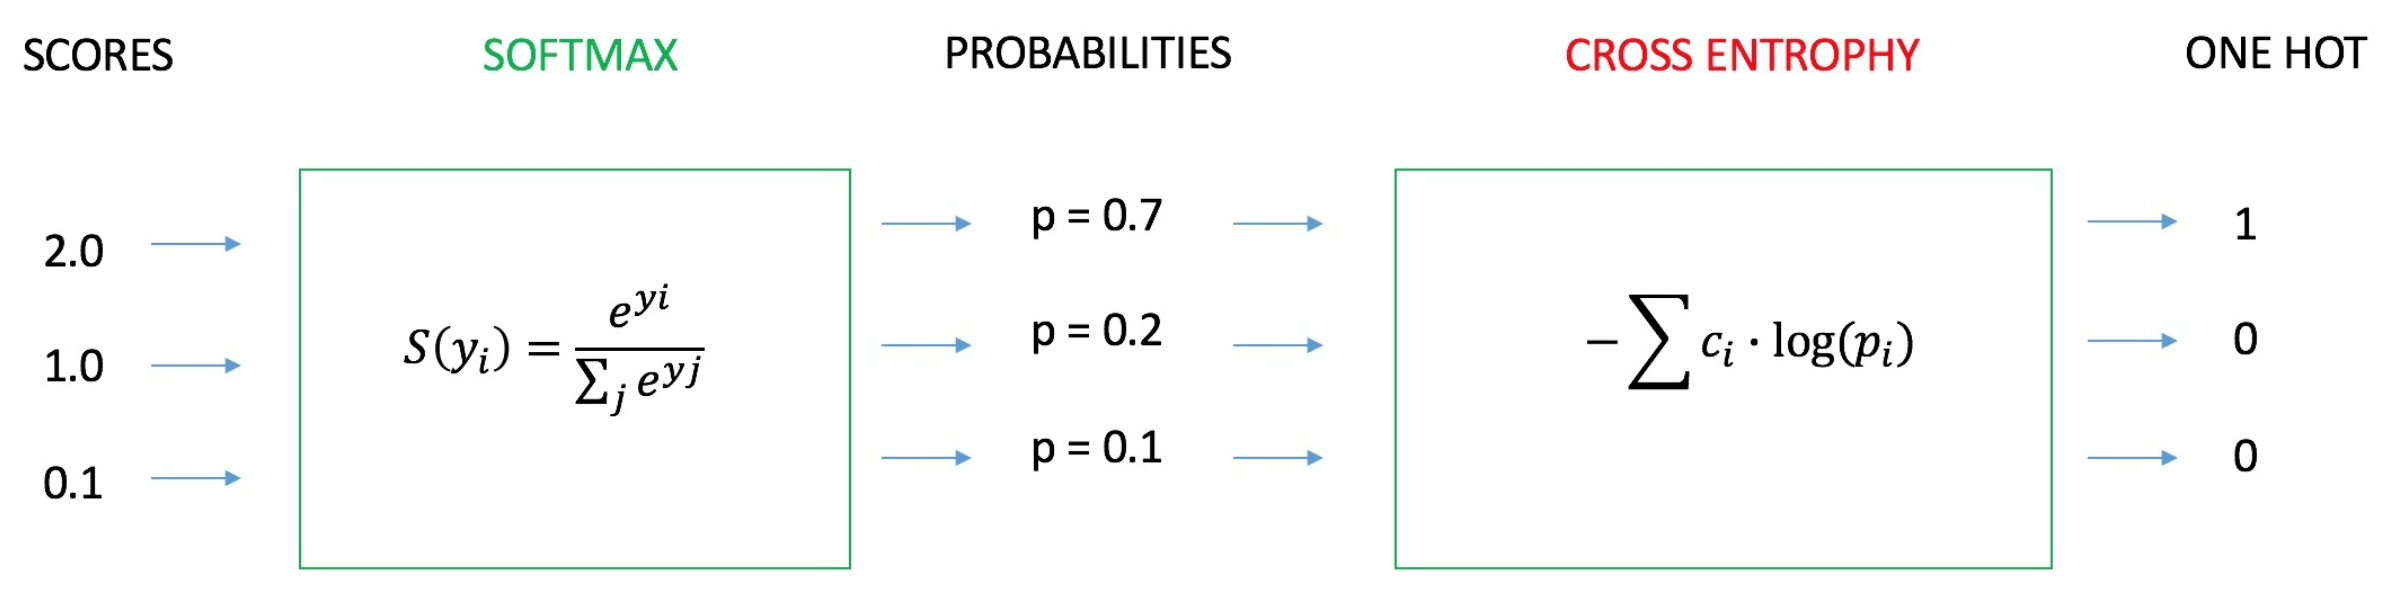

<br>
 


<font color=black size=3 face=雅黑>　　对于二元分类问题，其交叉熵损失函数写作：

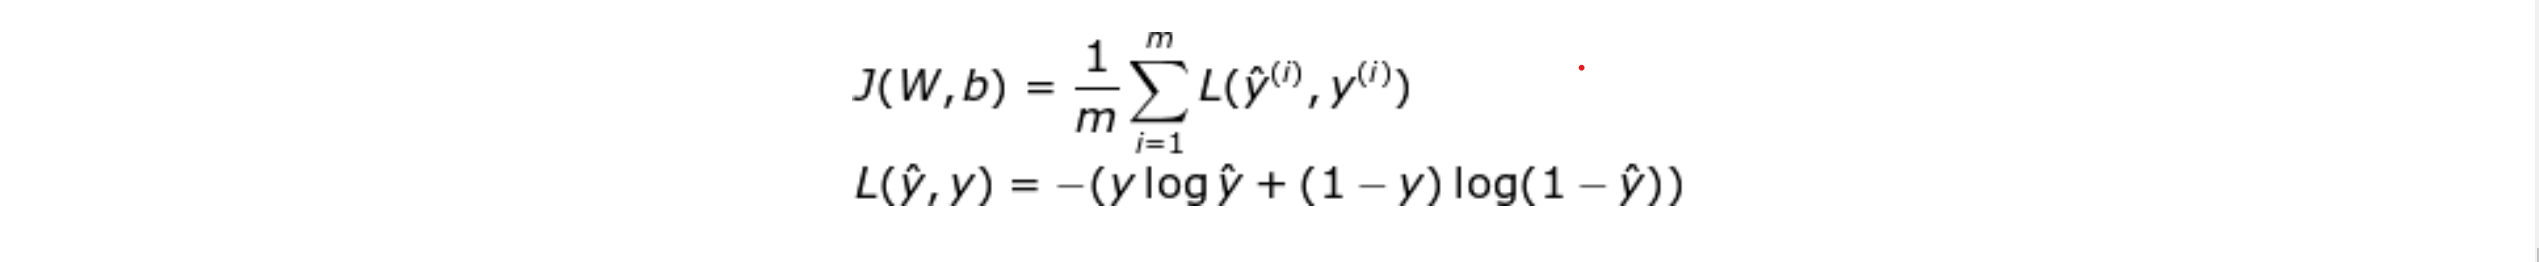

In [9]:
def get_cost_value(Y_hat, Y):    
    m = Y_hat.shape[1]  # number of samples (=900)
    
    # calculate the cost according to the formula
    # - Y: each element is either 0 or 1
    # - shape of Y & Y_hat: (1,900)
    # - shape of cost: (1,1)
    cost = -1 / m * (np.dot(Y, np.log(Y_hat).T) + np.dot(1 - Y, np.log(1 - Y_hat).T))
    
    return np.squeeze(cost)  # np.squeeze() -  从数组的形状中删除单维条目，即把shape中为1的维度去掉

<br>

<font color=black size=3 face=雅黑>　　为了取得更多关于学习过程的信息，我们还可以另外实现一个计算精确度的函数。
    
<br>

In [10]:
# an auxiliary function that converts probability into class
def convert_prob_into_class(probs):
    probs_ = np.copy(probs)
    probs_[probs_ > 0.5] = 1
    probs_[probs_ <= 0.5] = 0
    return probs_

def get_accuracy_value(Y_hat, Y):
    Y_hat_ = convert_prob_into_class(Y_hat)  # shape: (1,900), 900 = the number of samples (during training)
    accuracy = (Y_hat_ == Y).all(axis=0).mean()  # numpy.all(): 测试沿给定轴的所有数组元素是否都计算为True
                                                 # (Y_hat_ == Y).all(axis=0).shape = (900,)
                                                 # numpy.mean(): 求取均值
    return accuracy

<br />

### 8. 实现神经网络的反向传播过程

<br>

    
<font color=black size=3 face=雅黑>　　和前向传播一样，我们将把网络的反向传播过程拆分成两个函数来实现：

<font color=black size=3 face=雅黑>　　　　－　函数 8-1 (single_layer_backward_propagation)： 实现单个全连接层的反向传播过程

<font color=black size=3 face=雅黑>　　　　－　函数 8-2 (full_backward_propagation)： 基于函数 8-1，实现整个神经网络的反向传播过程

<br >  

#### <font color=black size=3 face=雅黑>8.1　函数 8-1 (single_layer_backward_propagation)： 实现单个全连接层的反向传播过程

<br>

<font color=black size=3 face=雅黑>　　下图显示了单个神经元上的前向传播和反向传播过程。对一个神经网络层 ($l$)，我们将接收来自 $l+1$ 层的 $da^{[l]}$，并根据前向传播时保存在 $memory$ 的中间数据 $z\_curr$ 和 $a\_prev$，计算 $loss$ 关于权重 **$𝑊^{[𝑙]}$** 和偏置 **$𝑏^{[𝑙]}$** 的偏导数—— **$d𝑊^{[𝑙]}$** 和 **$d𝑏^{[𝑙]}$** 。

<code>
%%html
<img src = "https://pic3.zhimg.com/v2-ffb7dc9760f74bc720f2745eda6d777e_r.jpg", width=70%>


<font color=black size=3 face=雅黑>　　下面的公式描述了单个全连接层上的反向传播过程。由于本次实验的重点在于实际实现，所以此处省略求导过程，感兴趣的同学请阅读课本相关章节。从公式上我们可以很明显地看出，为什么之前需要在前向传播时记住中间层的 $a\_prev$ 和 $z\_curr$ 。

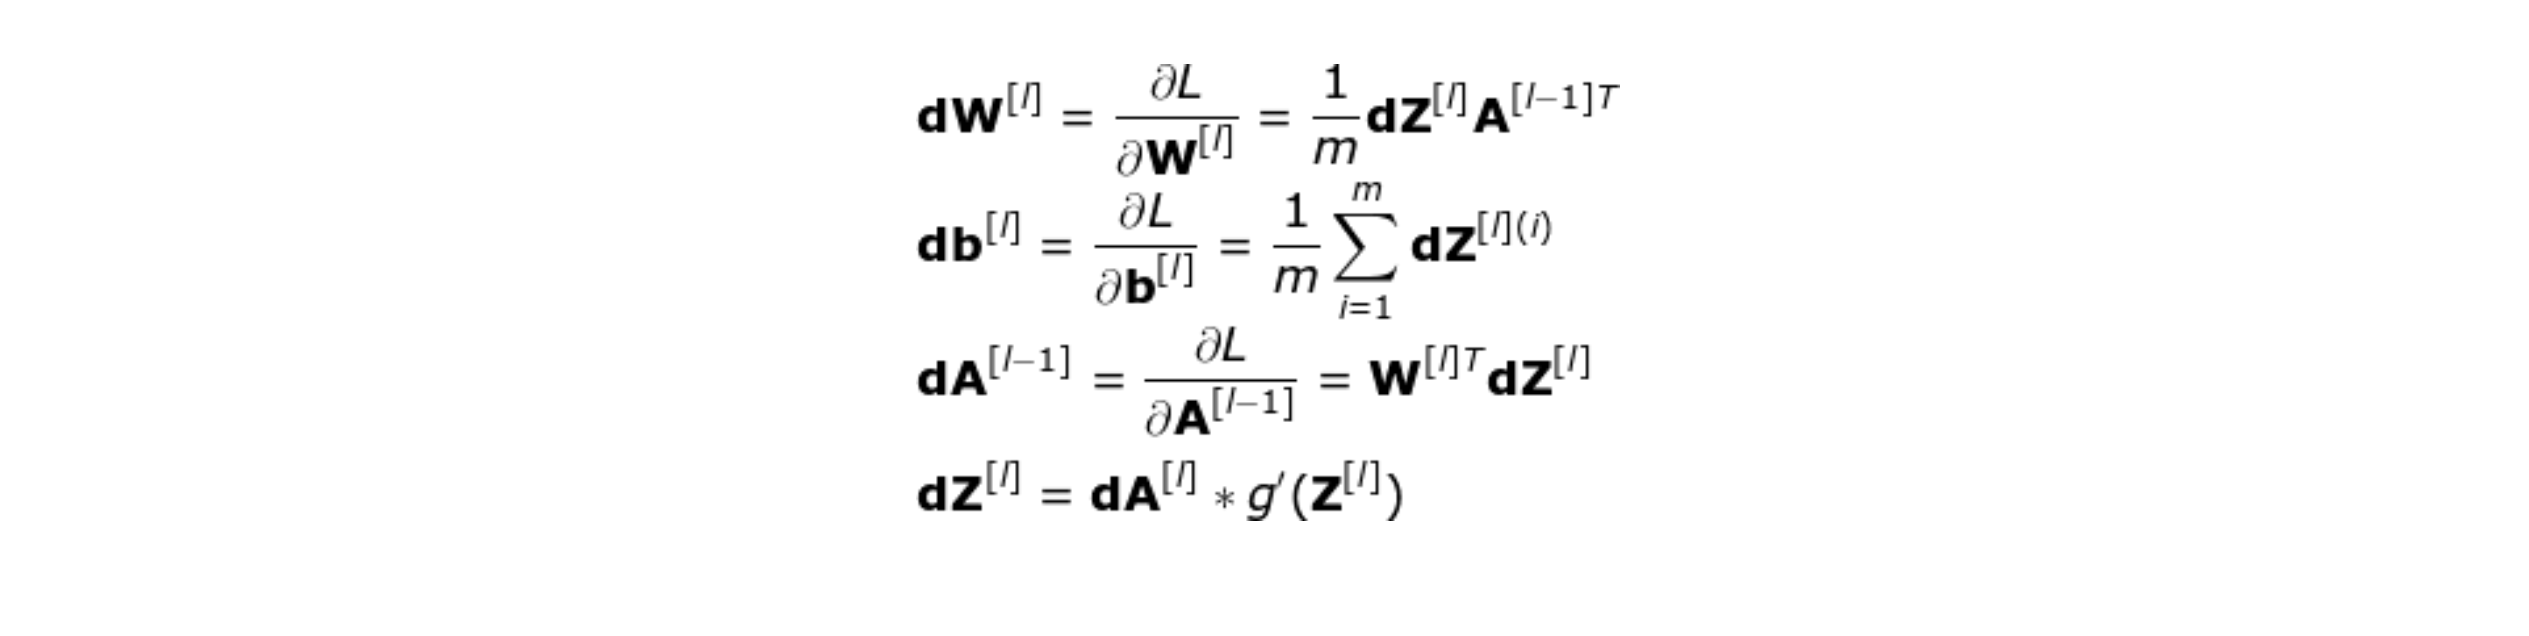

In [11]:
def single_layer_backward_propagation(dA_curr, W_curr, b_curr, Z_curr, A_prev, activation="relu"):
    
    m = A_prev.shape[1]  # number of examples
    
    # select the activation function
    if activation == "relu":
        backward_activation_func = relu_backward
    elif activation == "sigmoid":
        backward_activation_func = sigmoid_backward
    else:
        raise Exception('Non-supported activation function')

    # step-1: {dA_curr, Z_curr} -> dZ_curr 
    dZ_curr = backward_activation_func(dA_curr, Z_curr)
    
    
    # step-2: {dZ_curr, A_prev} -> dW_curr 
    #         dZ_curr -> db_curr 
    
    ###############  Please finish this part  ################
    
    # [Hint]: get dW_curr from dZ_curr and A_prev
    #   dW_curr = np.dot(XXX，XXX) / m
    
    # 计算权重矩阵的梯度: dW_curr = (1/m) * dZ_curr @ A_prev^T
    # dZ_curr 形状: (output_dim, m)
    # A_prev 形状: (input_dim, m)
    # 需要转置 A_prev: A_prev^T 形状为 (m, input_dim)
    # 结果 dW_curr 形状: (output_dim, input_dim)
    dW_curr = np.dot(dZ_curr, A_prev.T) / m

    ########################  end  ###########################
    
    db_curr = np.sum(dZ_curr, axis=1, keepdims=True) / m  # np.sum(): sum of array elements over a given axis
    # or, you can write it as:
    # db_curr = np.dot(dZ_curr, np.ones((dZ_curr.shape[1], 1))) / m  # dZ_curr.shape[1] = 900
    
    
    # step-3: {dZ_curr, W_curr} -> dA_prev (derivative of the matrix A_prev)
    
    ###############  Please finish this part  ################

    # [Hint]: get dA_prev from dZ_curr and W_curr
    #   dA_prev = np.dot(XXX，XXX)
    
    # 计算前一层激活值的梯度: dA_prev = W_curr^T @ dZ_curr
    # W_curr 形状: (output_dim, input_dim)
    # 需要转置 W_curr: W_curr^T 形状为 (input_dim, output_dim)
    # dZ_curr 形状: (output_dim, m)
    # 结果 dA_prev 形状: (input_dim, m)
    dA_prev = np.dot(W_curr.T, dZ_curr)
    
    
    ########################  end  ###########################

    return dA_prev, dW_curr, db_curr

<br>

#### <font color=black size=3 face=雅黑>8.2　函数 8-2 (full_backward_propagation)： 实现整个神经网络的反向传播过程

<br>
    
<font color=black size=3 face=雅黑>　　基于单个网络层的反向传播函数，我们从最后一层开始迭代计算所有参数上的导数（$dW$ 和 $db$），并最终返回包含所需梯度的字典。为了计算各层导数，函数需要输入前向传播时的网络输出 $y\_hat$ 和标准结果 $y$，并交由损失函数计算 $loss$。$loss$ 对于 $y\_hat$ 的偏导数可计算如下：
    
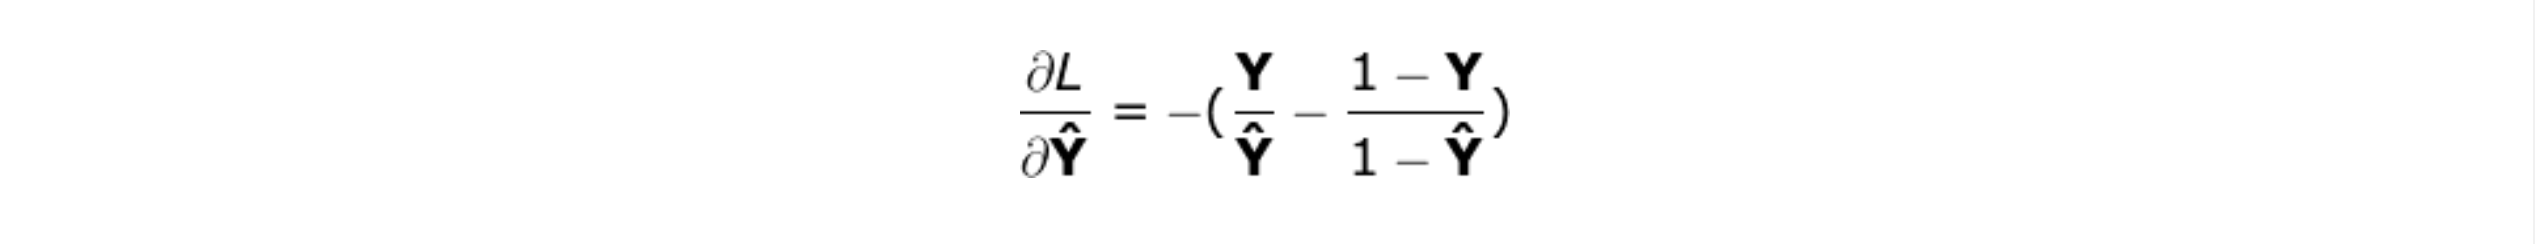
    
<font color=black size=3 face=雅黑>　　此外，函数还需要输入如下信息：

<font color=black size=3 face=雅黑>　　　　- 前向传播时的中间数据 $memory$ (含 $a\_prev$ 和 $z\_curr$) —— 用以计算各层的 $dW$ 和 $db$；

<font color=black size=3 face=雅黑>　　　　- 神经网络的参数 $params\_values$ —— 用以计算各层的 $da\_prev$。
    
<br>
    
<font color=black size=3 face=雅黑>　　函数的输出是各层的 $dW$ 和 $db$，保存在 $grads\_values$ 中。
    
<br>

<font color=black size=3 face=雅黑>　　在编写函数8-2前，我们先来试验一下等下将怎样从最后一层开始，向前逐层处理网络：

In [ ]:
# let's see how we will access each layer in the backward pass
for layer_idx_prev, layer in reversed(list(enumerate(nn_architecture_a))):  # we will use this code line in the following function
    print(layer_idx_prev)  # from 4 to 0
    print(layer)  # from layer L to layer 1 (we number network layers from 1)

4
{'input_dim': 25, 'output_dim': 1, 'activation': 'sigmoid'}
3
{'input_dim': 50, 'output_dim': 25, 'activation': 'relu'}
2
{'input_dim': 50, 'output_dim': 50, 'activation': 'relu'}
1
{'input_dim': 25, 'output_dim': 50, 'activation': 'relu'}
0
{'input_dim': 2, 'output_dim': 25, 'activation': 'relu'}


In [ ]:
def full_backward_propagation(Y_hat, Y, memory, params_values, nn_architecture_a):
    
    grads_values = {}    
    m = Y.shape[1]  # number of examples (Y.shape=(1,900))    
    Y = Y.reshape(Y_hat.shape)  # a hack ensuring the same shape of the prediction vector and labels vector
    
    # start the gradient descent algorithm
    dA_prev = - (np.divide(Y, Y_hat) - np.divide(1 - Y, 1 - Y_hat));
    
    for layer_idx_prev, layer in reversed(list(enumerate(nn_architecture_a))):
        
        layer_idx_curr = layer_idx_prev + 1  # note: we number network layers from 1
        activ_function_curr = layer["activation"]  # activation function for the current layer
        
        dA_curr = dA_prev        
        A_prev = memory["A" + str(layer_idx_prev)]
        Z_curr = memory["Z" + str(layer_idx_curr)]
        
        W_curr = params_values["W" + str(layer_idx_curr)]
        b_curr = params_values["b" + str(layer_idx_curr)]
        
        dA_prev, dW_curr, db_curr = single_layer_backward_propagation(
            dA_curr, W_curr, b_curr, Z_curr, A_prev, activ_function_curr)
        
        grads_values["dW" + str(layer_idx_curr)] = dW_curr
        grads_values["db" + str(layer_idx_curr)] = db_curr
    
    return grads_values

<br />

### 9. 更新参数值

<br>

    
<font color=black size=3 face=雅黑>　　反向传播是为了计算梯度，以根据梯度进行优化，更新网络的参数值。为了完成这一任务，我们将使用如下两组数据：
    
<font color=black size=3 face=雅黑>　　　- $params\_values$，其中保存了当前参数值；
    
<font color=black size=3 face=雅黑>　　　- $grads\_values$，其中保存了用于更新参数值所需的梯度信息。

<br>   
    
<font color=black size=3 face=雅黑>　　接下来我们只需在每个网络层上应用以下公式即可。其中，$\alpha$ 指学习率 (learning rate)。
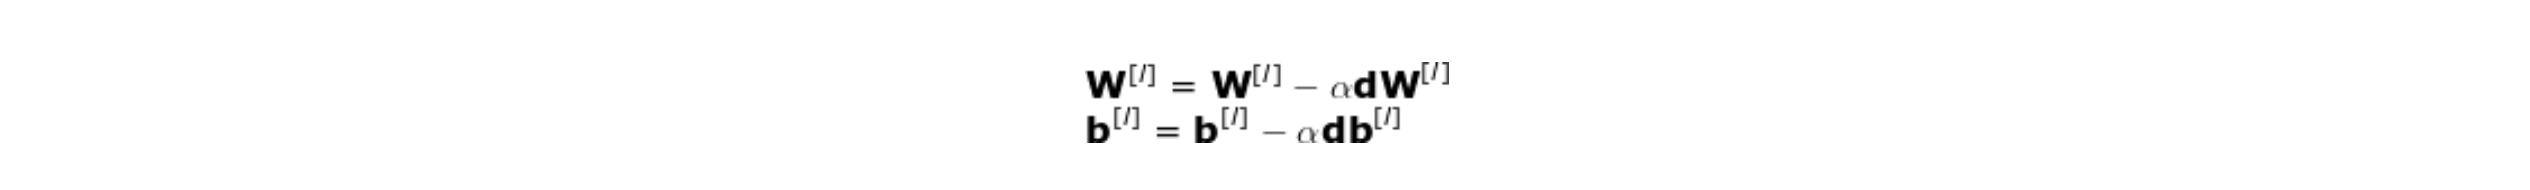

In [ ]:
def update(params_values, grads_values, nn_architecture_a, learning_rate):
    for idx, layer in enumerate(nn_architecture_a):
        layer_idx = idx + 1
        
        ###############  Please finish this part  ################
        
        # [Hint]: update params_values
        #   params_values["W" + str(layer_idx)] = XXX
        #   params_values["b" + str(layer_idx)] = XXX

        # 根据梯度下降算法更新权重: W = W - α * dW
        # 其中 α 是学习率 learning_rate
        params_values["W" + str(layer_idx)] = params_values["W" + str(layer_idx)] - learning_rate * grads_values["dW" + str(layer_idx)]
        
        # 根据梯度下降算法更新偏置: b = b - α * db
        params_values["b" + str(layer_idx)] = params_values["b" + str(layer_idx)] - learning_rate * grads_values["db" + str(layer_idx)]

        
        ########################  end  ###########################

    return params_values


<br />

### 10. 整合：完成 train 函数

<br>

    
<font color=black size=3 face=雅黑>　　到目前为止，我们已经完成了最困难的部分，准备好了所需的函数，接下来只需以正确的顺序把它们整合到一起。为了更好地理解每一步操作的顺序，请同学们再次查看“0. 概览”中的训练流程图。
    
<font color=black size=3 face=雅黑>　　train 函数将返回经过训练优化后的参数值，并显示在训练期间模型在训练集上的准确率。后期在测试集上，只需使用训练好的模型参数并运行一次完整的前向传播过程即可。

<br>

In [ ]:
def train(X, Y, nn_architecture_a, epochs, learning_rate, verbose=True, callback=None):
    
    # initialize the neural network parameters
    params_values = init_layers(nn_architecture_a, 2)
    
    # lists recording the loss & accuracy during the learning process 
    cost_history = []
    accuracy_history = []
    
    for i in range(epochs):
        # step forward
        Y_hat, cache = full_forward_propagation(X, params_values, nn_architecture_a)
        
        if i==1:
            print("X.shape: ", X.shape)  # (2, 900)
            print("Y_hat.shape: ", Y_hat.shape)  # (1, 900)
            print("Y.shape: ", Y.shape)  # (1, 900)
        
        # calculate loss & accuracy
        cost = get_cost_value(Y_hat, Y)
        cost_history.append(cost)
        accuracy = get_accuracy_value(Y_hat, Y)
        accuracy_history.append(accuracy)
        
        # step backward - calculating gradient
        grads_values = full_backward_propagation(Y_hat, Y, cache, params_values, nn_architecture_a)
        
        # update model state
        params_values = update(params_values, grads_values, nn_architecture_a, learning_rate)
        
        if(i % 50 == 0):
            if(verbose):
                print("Iteration: {:05} - cost: {:.5f} - accuracy: {:.5f}".format(i, cost, accuracy))
            if(callback is not None):
                callback(i, params_values)
            
    return params_values

### 11. 数据集准备

<br>

    
<font color=black size=3 face=雅黑>　　现在是时候尝试应用我们的模型来解决一个简单的分类问题。为了检测模型是否能够顺利训练，下面我们将生成一个二分类点集（如下图所示，两个类别的点分别用不同颜色表示），然后尝试训练模型来对这些点进行分类（二元分类问题）。

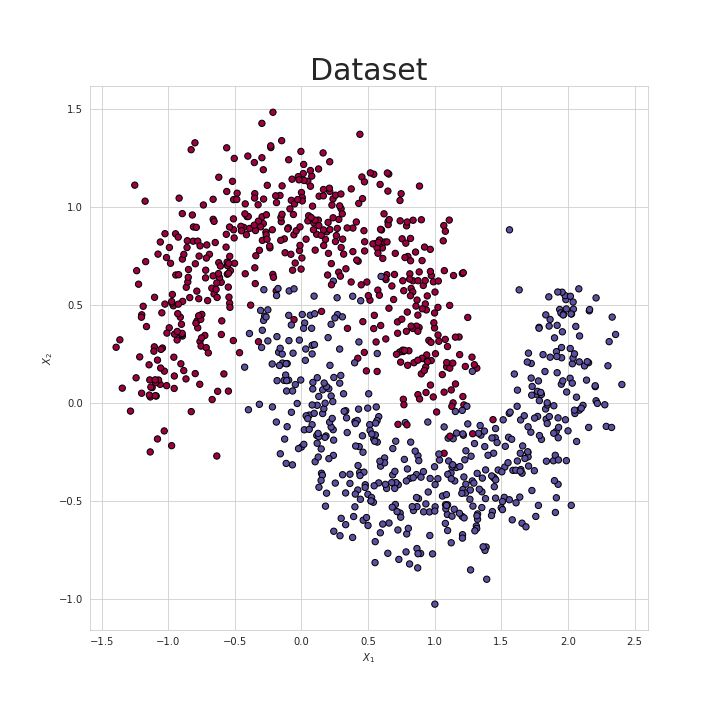

In [16]:
# number of samples in the dataset （training + test）
N_SAMPLES = 1000
# ratio of the test set
TEST_SIZE = 0.1

In [17]:
# we will use sklearn.make_moons() to generate the dataset:
#  - n_samples: 生成样本数量
#  - noise: 高斯噪声
#  - random_state: 生成随机种子，给定一个int型数据，能够保证每次生成数据相同
X, y = make_moons(n_samples = N_SAMPLES, noise=0.2, random_state=100)

# split the dataset into training set (90%) & test set (10%)
#  - test_size: 如果是浮点数，则应该在0.0和1.0之间，表示要测试集占总数据集的比例；如果是int类型，表示测试集的绝对数量。
#  - random_state: 随机数生成器使用的种子
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=42)

<br>

<font color=black size=3 face=雅黑>　　下面我们来观察一下刚刚生成好的数据集。
    
<br>

In [18]:
# check the information in X
print("shape of X: ", X.shape)  # (1000,2)
print("X = ", X)

# check the information in X_train
print("shape of X: ", X_train.shape)

shape of X:  (1000, 2)
X =  [[ 2.24907069e-05  1.07275825e+00]
 [-5.59037377e-02  4.25241282e-01]
 [ 2.40944879e-02  4.08065802e-01]
 ...
 [ 1.75841594e+00 -5.77404262e-01]
 [ 1.26710180e+00 -4.42980152e-01]
 [-1.75927072e-01  5.83509936e-01]]
shape of X:  (900, 2)


In [19]:
# check the information in Y
print("shape of Y: ", y.shape)  # (1000,)
print("number of zeros in Y: ", np.sum(y==0))  # 500
print("number of ones in Y: ", np.sum(y==1))  # 500
print("Y = ", y)

shape of Y:  (1000,)
number of zeros in Y:  500
number of ones in Y:  500
Y =  [0 0 1 0 1 0 0 1 1 1 1 1 0 1 1 0 0 1 0 1 1 0 1 0 0 1 1 0 1 1 1 0 0 0 0 1 1
 1 0 0 0 0 0 0 1 0 1 0 1 0 0 1 0 0 0 0 1 1 1 0 0 1 1 0 1 0 0 0 0 0 1 1 1 0
 1 0 0 1 0 1 1 1 1 0 1 0 1 1 0 1 0 0 1 0 0 1 0 0 0 0 1 1 0 1 1 0 0 0 1 0 0
 0 0 1 1 0 0 0 1 0 1 1 0 0 1 1 0 0 1 1 0 0 1 0 0 0 1 0 0 1 1 0 0 0 1 0 0 0
 0 1 0 1 1 1 1 0 1 1 1 0 1 1 0 0 1 0 1 0 1 1 0 0 1 0 1 0 0 1 1 1 1 1 0 1 1
 0 0 0 0 0 1 0 1 0 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0
 1 1 0 1 0 0 1 1 0 1 0 0 0 0 1 1 1 1 0 0 0 0 0 1 0 0 1 1 1 0 1 1 1 1 1 1 1
 0 0 0 0 0 0 1 1 1 1 0 1 0 0 0 1 1 1 0 0 1 0 1 1 1 0 0 1 0 0 0 1 1 0 1 0 0
 1 1 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 1 0 1 0 1 0 1 0 0 1 0 1 1
 0 0 1 0 1 1 0 0 1 1 1 1 0 0 1 1 0 1 1 0 1 1 0 1 1 0 0 1 0 0 1 0 0 0 1 1 0
 0 1 1 1 1 0 0 0 0 1 0 0 0 0 1 1 0 1 1 1 0 0 1 0 1 0 1 1 0 0 1 0 1 1 1 1 0
 1 0 0 0 0 1 0 0 0 0 0 0 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 0 1 0 0 1 1 1 1 0
 1 1 1 0 1 1 1 1 1 0 

In [20]:
# making up the graph of the dataset
def make_plot(X, y, plot_name, file_name=None, XX=None, YY=None, preds=None, dark=False):
    if (dark):
        plt.style.use('dark_background')
    else:
        sns.set_style("whitegrid")
    plt.figure(figsize=(16,12))
    axes = plt.gca()
    axes.set(xlabel="$X_1$", ylabel="$X_2$")
    plt.title(plot_name, fontsize=30)
    plt.subplots_adjust(left=0.20)
    plt.subplots_adjust(right=0.80)
    if(XX is not None and YY is not None and preds is not None):
        plt.contourf(XX, YY, preds.reshape(XX.shape), 25, alpha = 1, cmap=cm.Spectral)
        plt.contour(XX, YY, preds.reshape(XX.shape), levels=[.5], cmap="Greys", vmin=0, vmax=.6)
    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), s=40, cmap=plt.cm.Spectral, edgecolors='black')
    if(file_name):
        plt.savefig(file_name)
        plt.close()

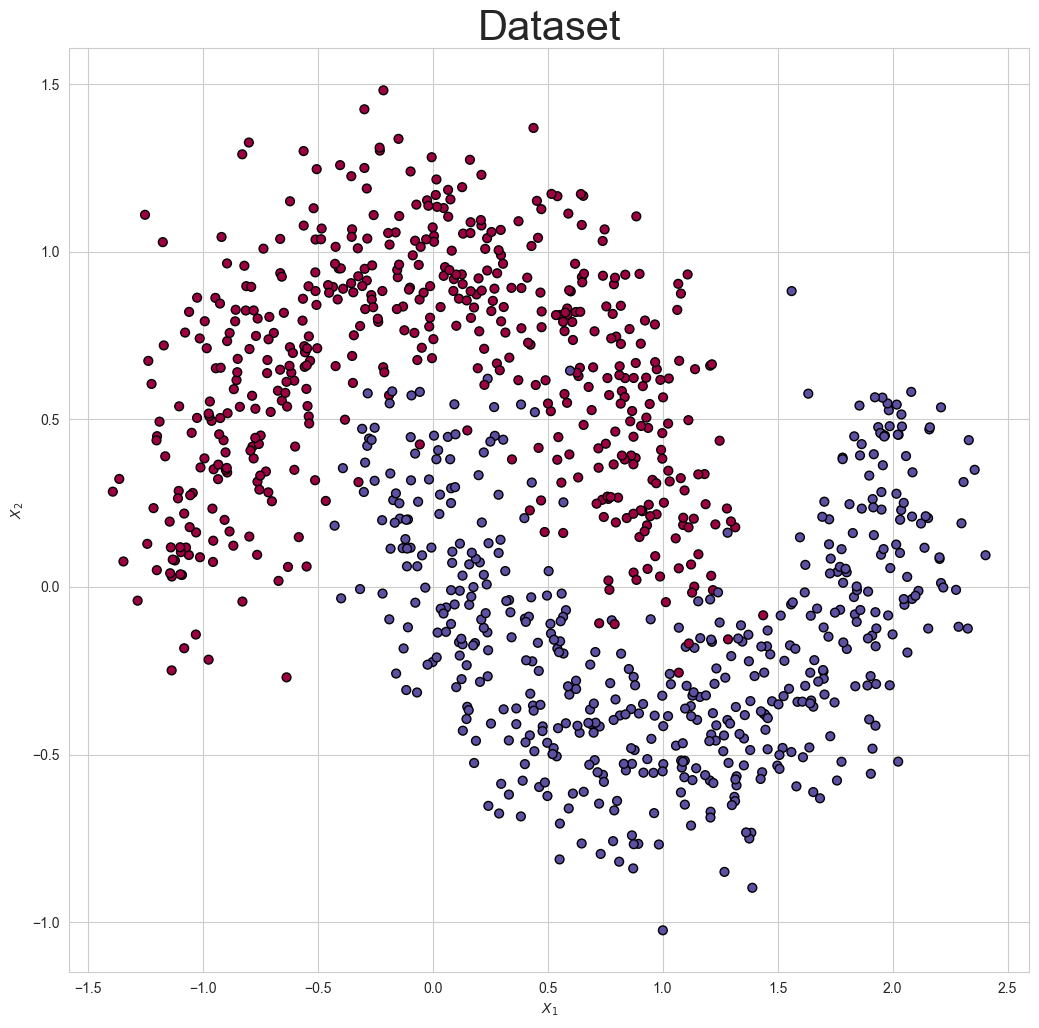

In [21]:
# plot the dataset
make_plot(X, y, "Dataset")

<br>

<font color=black size=3 face=雅黑>　　请同学们依次尝试将 sklearn.make_moons() 函数中 noise 取 0, 0.2, 0.4, 0.8, 1.0 等不同值，查看并截图保存对应的数据集图像和训练结果，分析其趋势，及出现这样趋势的原因。
    
<font color=black size=3 face=雅黑>　　然后，请同学们将 sklearn.make_moons() 中 noise 固定为 0.8，将sklearn.model_selection.train_test_split() 函数中的 TEST_SIZE 改为 0.98，观察和原先 noise 为 0.2、TEST_SIZE 为 0.1 的情况相比，训练集上的准确度和测试集上的准确度都分别发生了什么变化？出现这样变化的原因是什么？
    
<br>

<br>

### 12. 模型训练及测试

<br>

    
<font color=black size=3 face=雅黑>　　下面我们来调用 train 函数对模型进行训练。
    
<br>

In [ ]:
# let's train the neural network
params_values = train(X=np.transpose(X_train), Y=np.transpose(y_train.reshape((y_train.shape[0], 1))), 
                      nn_architecture_a=nn_architecture_a, epochs=10000, learning_rate=0.01)

<br>

<font color=black size=3 face=雅黑>　　调用一次 full_forward_propagation()，在测试集上评估训练好的模型。

<br>

In [ ]:
# prediction
Y_test_hat, _ = full_forward_propagation(np.transpose(X_test), params_values, nn_architecture_a)

In [ ]:
# accuracy achieved on the test set
acc_test = get_accuracy_value(Y_test_hat, np.transpose(y_test.reshape((y_test.shape[0], 1))))
print("Test set accuracy: {:.2f}".format(acc_test))

<br>

<font color=black size=3 face=雅黑>　　请同学们将 learning_rate 分别改为 0.1 和 0.001，观察训练过程中的 cost 和 accuracy 变化趋势，并分析其原因。

<br>

<br>
<br>

## 实验报告

<br>

<font color=black size=3 face=雅黑> 1. 完成整个实验，结果截图保存，并对各部分的代码和结果进行解释说明。请特别注意补全空缺代码，并逐条说明这样编程的原因。
    
<font color=black size=3 face=雅黑> 2. 参考第6.1节的图，画出第二层和第三层网络在前向传播和反向传播时的矩阵运算：请用大小合适的矩形代表矩阵和向量，并标明每个矩阵和向量的维度。
    
<font color=black size=3 face=雅黑> 3. 根据第3节的说明，尝试不同的网络结构，看看训练结果是否有什么不同，分析其趋势及原因。
    
<font color=black size=3 face=雅黑> 5. 根据第4.3节的说明，尝试将网络参数全部初始化为0，观察训练结果并分析原因。
    
<font color=black size=3 face=雅黑> 6. 根据第11节的说明，调整 make_moons() 函数中的 noise 和 train_test_split() 函数中的 TEST_SIZE，改变数据集中样本点的分布，并对结果进行分析。
    
<font color=black size=3 face=雅黑> 7. 根据第12节的说明，请将 learning_rate 分别改为 0.1 和 0.001，观察训练过程中的 cost 和 accuracy 变化趋势，并分析其原因。
    
<br>
<br>

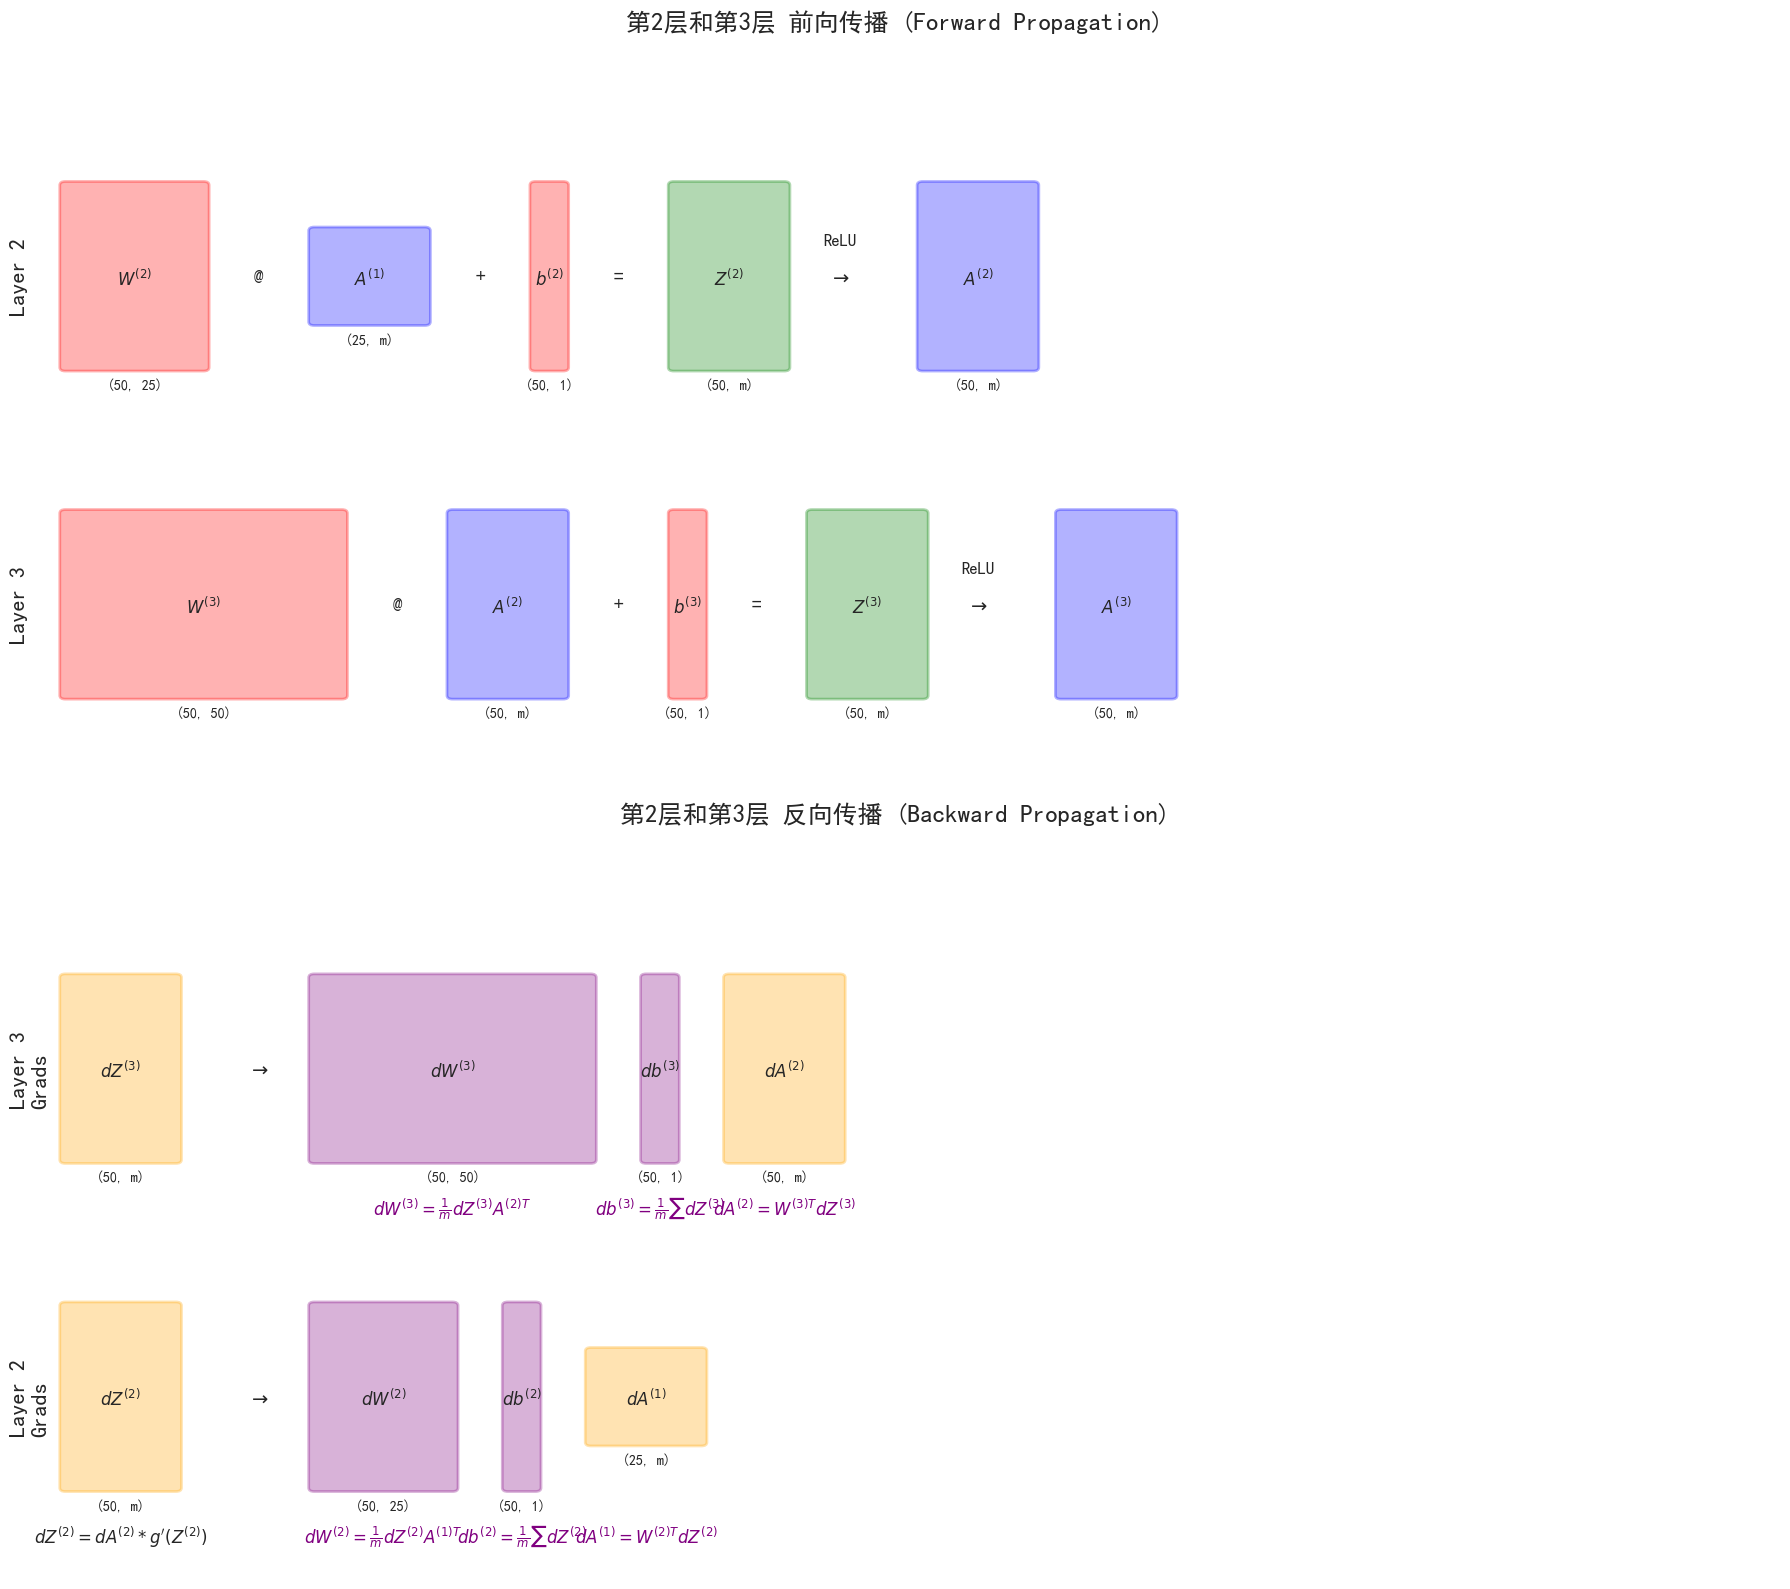

矩阵运算图表已生成并保存为 matrix_operations_layer2_3.png


In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 配置中文字体支持
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def draw_matrix(ax, x, y, h, w, text, color, subtext=None):
    """绘制一个代表矩阵的矩形"""
    rect = mpatches.FancyBboxPatch((x, y - h/2), w, h, boxstyle="round,pad=0.1", 
                                   edgecolor=color, facecolor=color, alpha=0.3, linewidth=2)
    ax.add_patch(rect)
    # 主标签
    ax.text(x + w/2, y, text, ha='center', va='center', fontsize=12, fontweight='bold')
    # 维度标签
    if subtext:
        ax.text(x + w/2, y - h/2 - 0.3, subtext, ha='center', va='top', fontsize=10)
    return x + w

def draw_symbol(ax, x, y, symbol):
    """绘制运算符号"""
    ax.text(x, y, symbol, ha='center', va='center', fontsize=14, fontweight='bold')

fig, (ax_fwd, ax_bwd) = plt.subplots(2, 1, figsize=(18, 16))

# 比例因子
H_SCALE = 0.1   # 高度缩放
W_SCALE = 0.1   # 宽度缩放
M_WIDTH = 2.0   # 样本数m的宽度
BIAS_WIDTH = 0.5 # 偏置向量的宽度
SPACING = 1.0   # 元素间距

# ==================== 前向传播 (Forward) ====================
ax_fwd.set_title("第2层和第3层 前向传播 (Forward Propagation)", fontsize=18, pad=20)
ax_fwd.set_xlim(0, 32)
ax_fwd.set_ylim(0, 20)
ax_fwd.axis('off')

# --- Layer 2 (25 -> 50) ---
y_l2 = 14.0
x = 1.0

# W2 (50x25)
h_out = 50 * H_SCALE
w_in = 25 * W_SCALE
draw_matrix(ax_fwd, x, y_l2, h_out, w_in, r"$W^{(2)}$", 'red', "(50, 25)")
x += w_in + SPACING

draw_symbol(ax_fwd, x, y_l2, "@")
x += SPACING

# A1 (25xm)
h_in = 25 * H_SCALE
draw_matrix(ax_fwd, x, y_l2, h_in, M_WIDTH, r"$A^{(1)}$", 'blue', "(25, m)")
x += M_WIDTH + SPACING

draw_symbol(ax_fwd, x, y_l2, "+")
x += SPACING

# b2 (50x1)
draw_matrix(ax_fwd, x, y_l2, h_out, BIAS_WIDTH, r"$b^{(2)}$", 'red', "(50, 1)")
x += BIAS_WIDTH + SPACING

draw_symbol(ax_fwd, x, y_l2, "=")
x += SPACING

# Z2 (50xm)
draw_matrix(ax_fwd, x, y_l2, h_out, M_WIDTH, r"$Z^{(2)}$", 'green', "(50, m)")
x += M_WIDTH + SPACING

draw_symbol(ax_fwd, x, y_l2, r"$\rightarrow$")
ax_fwd.text(x, y_l2 + 0.8, "ReLU", ha='center', va='bottom', fontsize=12, fontweight='bold')
x += SPACING + 0.5

# A2 (50xm)
draw_matrix(ax_fwd, x, y_l2, h_out, M_WIDTH, r"$A^{(2)}$", 'blue', "(50, m)")

ax_fwd.text(0.0, y_l2, "Layer 2", fontsize=16, fontweight='bold', rotation=90, va='center')


# --- Layer 3 (50 -> 50) ---
y_l3 = 5.0
x = 1.0

# W3 (50x50)
h_out = 50 * H_SCALE
w_in = 50 * W_SCALE
draw_matrix(ax_fwd, x, y_l3, h_out, w_in, r"$W^{(3)}$", 'red', "(50, 50)")
x += w_in + SPACING

draw_symbol(ax_fwd, x, y_l3, "@")
x += SPACING

# A2 (50xm) - Input to L3
h_in = 50 * H_SCALE
draw_matrix(ax_fwd, x, y_l3, h_in, M_WIDTH, r"$A^{(2)}$", 'blue', "(50, m)")
x += M_WIDTH + SPACING

draw_symbol(ax_fwd, x, y_l3, "+")
x += SPACING

# b3 (50x1)
draw_matrix(ax_fwd, x, y_l3, h_out, BIAS_WIDTH, r"$b^{(3)}$", 'red', "(50, 1)")
x += BIAS_WIDTH + SPACING

draw_symbol(ax_fwd, x, y_l3, "=")
x += SPACING

# Z3 (50xm)
draw_matrix(ax_fwd, x, y_l3, h_out, M_WIDTH, r"$Z^{(3)}$", 'green', "(50, m)")
x += M_WIDTH + SPACING

draw_symbol(ax_fwd, x, y_l3, r"$\rightarrow$")
ax_fwd.text(x, y_l3 + 0.8, "ReLU", ha='center', va='bottom', fontsize=12, fontweight='bold')
x += SPACING + 0.5

# A3 (50xm)
draw_matrix(ax_fwd, x, y_l3, h_out, M_WIDTH, r"$A^{(3)}$", 'blue', "(50, m)")

ax_fwd.text(0.0, y_l3, "Layer 3", fontsize=16, fontweight='bold', rotation=90, va='center')


# ==================== 反向传播 (Backward) ====================
ax_bwd.set_title("第2层和第3层 反向传播 (Backward Propagation)", fontsize=18, pad=20)
ax_bwd.set_xlim(0, 32)
ax_bwd.set_ylim(0, 20)
ax_bwd.axis('off')

# --- Layer 3 Backward ---
y_l3_bw = 14.0
x = 1.0

ax_bwd.text(0.0, y_l3_bw, "Layer 3\nGrads", fontsize=16, fontweight='bold', rotation=90, va='center')

# dZ3 (50xm)
h_out = 50 * H_SCALE
draw_matrix(ax_bwd, x, y_l3_bw, h_out, M_WIDTH, r"$dZ^{(3)}$", 'orange', "(50, m)")
x += M_WIDTH + SPACING + 0.5

# Arrows to dW3, db3, dA2
# dW3
draw_symbol(ax_bwd, x, y_l3_bw, r"$\rightarrow$")
x += SPACING
draw_matrix(ax_bwd, x, y_l3_bw, h_out, 50*W_SCALE, r"$dW^{(3)}$", 'purple', "(50, 50)")
ax_bwd.text(x + 50*W_SCALE/2, y_l3_bw - 4.0, r"$dW^{(3)} = \frac{1}{m} dZ^{(3)} A^{(2)T}$", ha='center', fontsize=12, color='purple')

x += 50*W_SCALE + SPACING

# db3
draw_matrix(ax_bwd, x, y_l3_bw, h_out, BIAS_WIDTH, r"$db^{(3)}$", 'purple', "(50, 1)")
ax_bwd.text(x + BIAS_WIDTH/2, y_l3_bw - 4.0, r"$db^{(3)} = \frac{1}{m} \sum dZ^{(3)}$", ha='center', fontsize=12, color='purple')

x += BIAS_WIDTH + SPACING

# dA2
draw_matrix(ax_bwd, x, y_l3_bw, 50*H_SCALE, M_WIDTH, r"$dA^{(2)}$", 'orange', "(50, m)")
ax_bwd.text(x + M_WIDTH/2, y_l3_bw - 4.0, r"$dA^{(2)} = W^{(3)T} dZ^{(3)}$", ha='center', fontsize=12, color='purple')


# --- Layer 2 Backward ---
y_l2_bw = 5.0
x = 1.0

ax_bwd.text(0.0, y_l2_bw, "Layer 2\nGrads", fontsize=16, fontweight='bold', rotation=90, va='center')

# dZ2 (50xm)
h_out = 50 * H_SCALE
draw_matrix(ax_bwd, x, y_l2_bw, h_out, M_WIDTH, r"$dZ^{(2)}$", 'orange', "(50, m)")
ax_bwd.text(x + M_WIDTH/2, y_l2_bw - 4.0, r"$dZ^{(2)} = dA^{(2)} * g'(Z^{(2)})$", ha='center', fontsize=12)

x += M_WIDTH + SPACING + 0.5

# Arrows to dW2, db2, dA1
# dW2
draw_symbol(ax_bwd, x, y_l2_bw, r"$\rightarrow$")
x += SPACING
draw_matrix(ax_bwd, x, y_l2_bw, h_out, 25*W_SCALE, r"$dW^{(2)}$", 'purple', "(50, 25)")
ax_bwd.text(x + 25*W_SCALE/2, y_l2_bw - 4.0, r"$dW^{(2)} = \frac{1}{m} dZ^{(2)} A^{(1)T}$", ha='center', fontsize=12, color='purple')

x += 25*W_SCALE + SPACING

# db2
draw_matrix(ax_bwd, x, y_l2_bw, h_out, BIAS_WIDTH, r"$db^{(2)}$", 'purple', "(50, 1)")
ax_bwd.text(x + BIAS_WIDTH/2, y_l2_bw - 4.0, r"$db^{(2)} = \frac{1}{m} \sum dZ^{(2)}$", ha='center', fontsize=12, color='purple')

x += BIAS_WIDTH + SPACING

# dA1
draw_matrix(ax_bwd, x, y_l2_bw, 25*H_SCALE, M_WIDTH, r"$dA^{(1)}$", 'orange', "(25, m)")
ax_bwd.text(x + M_WIDTH/2, y_l2_bw - 4.0, r"$dA^{(1)} = W^{(2)T} dZ^{(2)}$", ha='center', fontsize=12, color='purple')


plt.tight_layout()
plt.savefig('matrix_operations_layer2_3.png', dpi=150, bbox_inches='tight')
plt.show()

print("矩阵运算图表已生成并保存为 matrix_operations_layer2_3.png")